# Recursive subclustering

This notebook performs an iterative nested clustering to derive a supercluster, cluster and subcluster hierarchy on the Naked Mole-Rat data.

#### Workflow

1. Define local embedding: HVG, Scale, PCA, Replicate Integration.

2. Build graph using KNN

3. Cluster by leiden algorithm

4. Compute silhouette score

5. Accept or reject clustering children based on ther silhouette score

6. Recurse for each accepted children cluster if depth < 3

In [1]:
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import harmonypy as hm 


In [2]:
### parameters
hvgs_n = 3000 # 3000 are used for clusterings, but thet are increased during annotation to 6000
n_pcs = 20 # 15 are used for clusterings, but thet are increased during annotation to 50
supercluster_k = 25
supercluster_resolution = 0.1
local_hvg = 2000
local_pcs = 15
local_resolution = 0.5
batch_key = "sample"
seed = 42
depth = 3

## Load adata

In [3]:
rev_n = 12 # Use 12
region = 'hippocampus' # Options: 'cerebral_cortex', 'hippocampus'
input_path = f"/home/ratopin/big_data/nmr/{region}_nmr_adata_filtered{rev_n}.h5ad"

In [4]:
adata = sc.read_h5ad(input_path)

In [5]:
adata.obs_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


## Perform the subclustering

In [6]:
# 2. Add the parent directory to Python's search path
import sys
import os

# Get the path to the directory containing 'scripts/' 
# (assuming your notebook is in the project root or a sibling folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
scripts_path = os.path.join(project_root, "scripts")

if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# 3. Import your script
from adaptive_clustering import run_sc_annotation_pipeline


In [7]:
adata = run_sc_annotation_pipeline(
    adata, 
    batch_key=batch_key,        # Global batch key (e.g. for superclusters)
    replicate_key="replicate", # Local subclustering batch key (for HPO steps)
    hvgs_n=local_hvg,                # Low number for mock dataset speed
    n_pcs=n_pcs,
    supercluster_k=supercluster_k,
    supercluster_resolution=supercluster_resolution,
    max_depth=depth,               # Stop at depth 2 for quick dry-run
    sil_threshold=0.05,
    show_plots=False,            # Render the plots inline in this notebook
    random_state=seed
)

STEP 1: Processing Global Embeddings & Superclusters


/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py:151: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=hvgs_n, subset=False, flavor="seurat_v3", batch_key=batch_key)


/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py:157: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, svd_solver='arpack', n_comps=n_pcs, use_highly_variable=True)
2026-07-14 20:25:23,445 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-07-14 20:25:23,446 - harmonypy - INFO -   Parameters:
2026-07-14 20:25:23,447 - harmonypy - INFO -     max_iter_harmony: 20
2026-07-14 20:25:23,447 - harmonypy - INFO -     max_iter_kmeans: 3
2026-07-14 20:25:23,447 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-07-14 20:25:23,448 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-07-14


STEP 2: Running Recursive HPO Subclustering
--- Computing Superclusters ---


/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py:219: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


...

2026-07-14 20:28:09,385 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-14 20:28:09,392 - harmonypy - INFO - KMeans initialization complete.
2026-07-14 20:28:09,397 - harmonypy - INFO - Iteration 1 of 20
2026-07-14 20:28:09,413 - harmonypy - INFO - Iteration 2 of 20
2026-07-14 20:28:09,432 - harmonypy - INFO - Iteration 3 of 20
2026-07-14 20:28:09,453 - harmonypy - INFO - Iteration 4 of 20
2026-07-14 20:28:09,469 - harmonypy - INFO - Iteration 5 of 20
2026-07-14 20:28:09,484 - harmonypy - INFO - Iteration 6 of 20
2026-07-14 20:28:09,499 - harmonypy - INFO - Converged after 6 iterations
/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py:320: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='ig

[6] Harmony applied
[6] Split accepted → res=0.5 sil=0.104


/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py:361: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(
Traceback (most recent call last):
  File "/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py", line 268, in evaluate_and_split_node
    sc.pp.highly_variable_genes(
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py", line 88, in fn_compatible
    return fn(*args_all, **kw)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py", line 759, in highly_variable_genes
    return _highly_variable_genes_seurat_v3(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py", line 192, in _highly_v

[6/1] Sweeping HPO Depth 3
[6/0] Sweeping HPO Depth 3
[6/2] ⏭ Too few cells (23)
🎉 Recursive Custering with HPO completed


Traceback (most recent call last):
  File "/home/ratopin/single-nucleus-nmr/scripts/adaptive_clustering.py", line 268, in evaluate_and_split_node
    sc.pp.highly_variable_genes(
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py", line 88, in fn_compatible
    return fn(*args_all, **kw)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py", line 759, in highly_variable_genes
    return _highly_variable_genes_seurat_v3(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ratopin/miniconda3/envs/scanpy-env/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py", line 192, in _highly_variable_genes_seurat_v3
    model.fit()
  File "_loess.pyx", line 922, in _loess.loess.fit
ValueError: b'svddc failed in l2fit.'


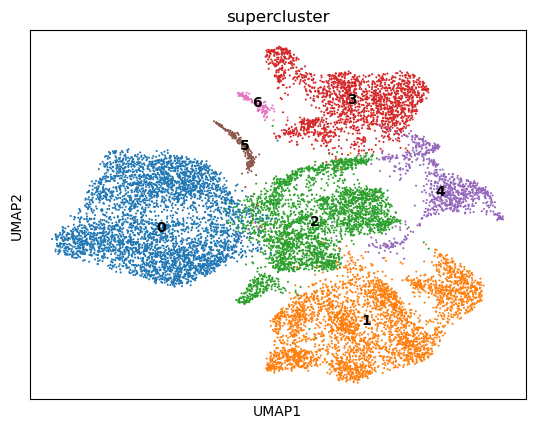

In [8]:
sc.pl.umap(adata, color="supercluster", legend_loc="on data")

/tmp/ipykernel_3400529/748766057.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


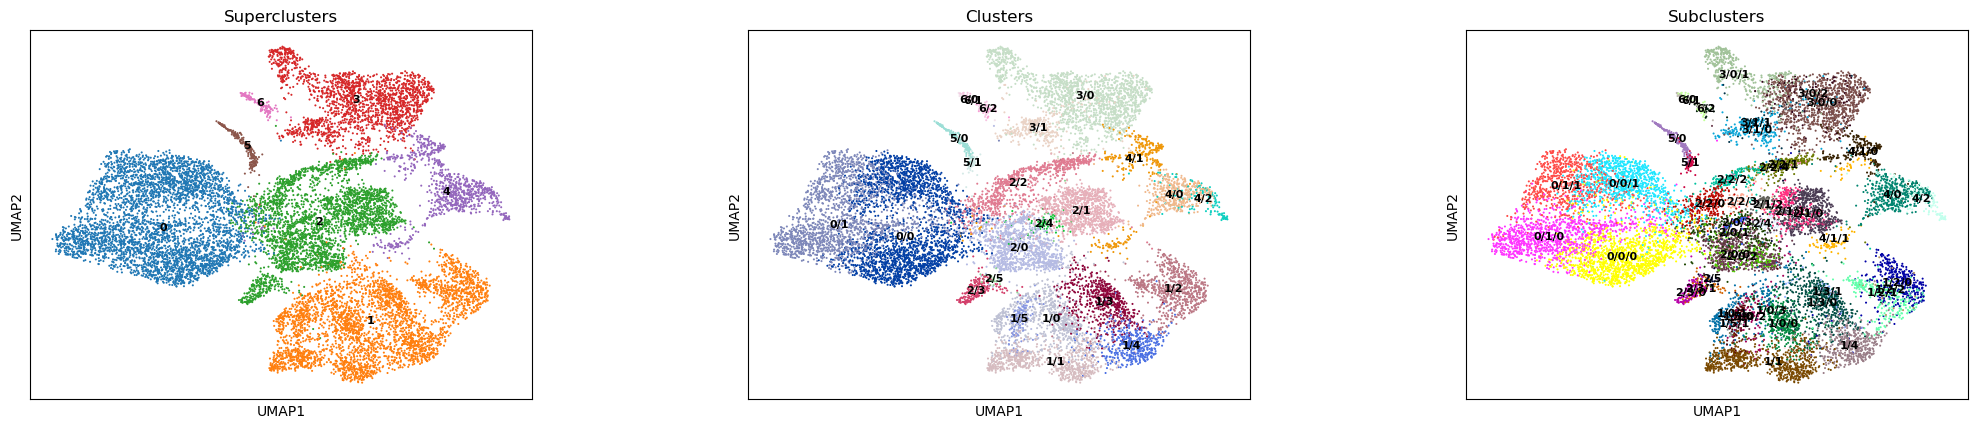

In [9]:
sc.pl.umap(
    adata, 
    color=['supercluster', 'cluster', 'subcluster'], 
    legend_loc='on data', 
    legend_fontsize=8,
    wspace=0.3,
    title=['Superclusters', 'Clusters', 'Subclusters'], 
    save=f"{region}_recursive_hpo_subclustering_umap.png"
)

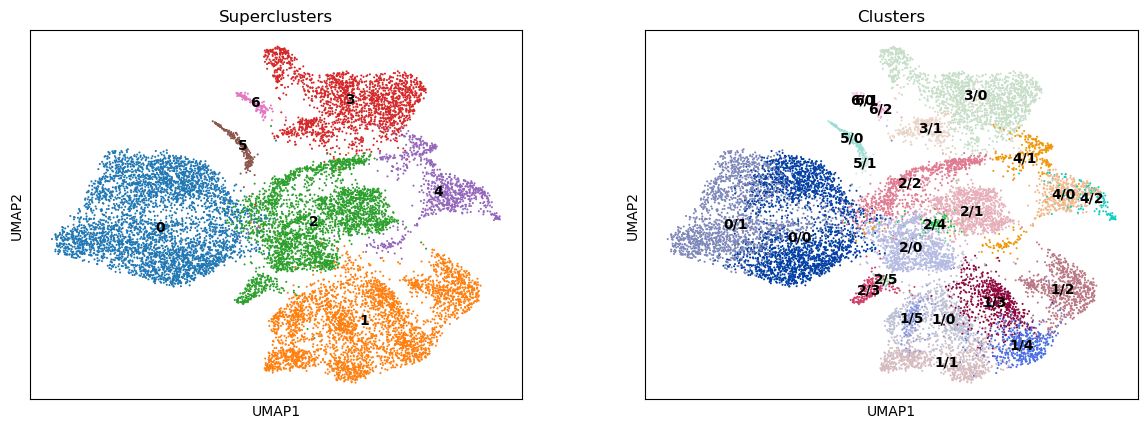

In [10]:
sc.pl.umap(
    adata, 
    color=['supercluster', 'cluster'], 
    legend_loc='on data', 
    legend_fontsize=10,
    title=['Superclusters', 'Clusters'])

In [11]:
adata

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'supercluster', 'cluster', 'subcluster'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'supercluster', 'uma

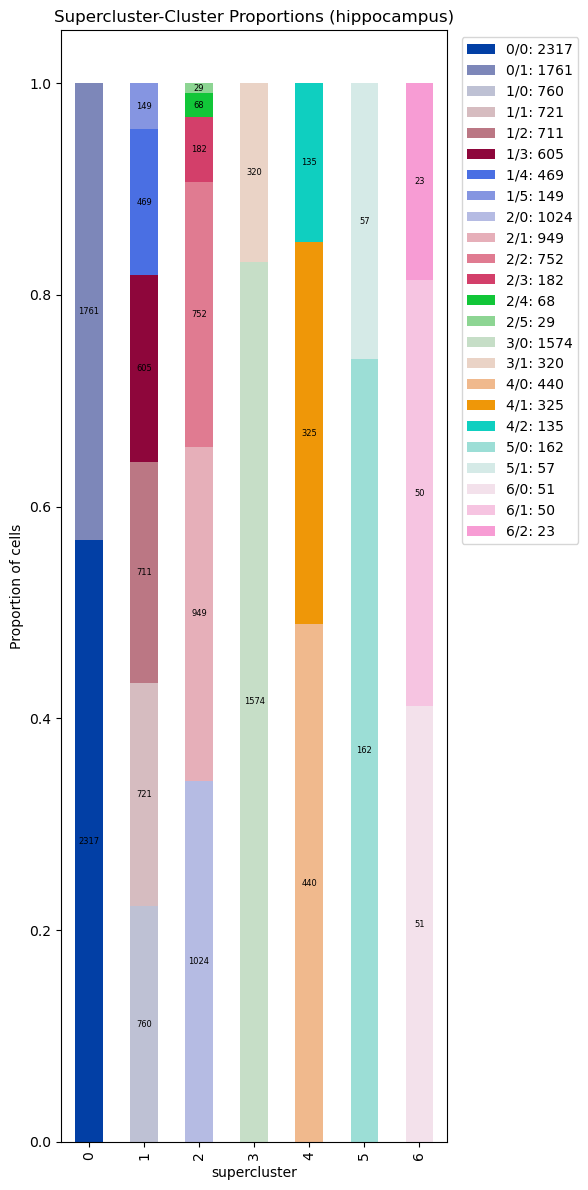

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. raw counts
counts = pd.crosstab(
    adata.obs['supercluster'],
    adata.obs['cluster']
)

# 2. proportions
proportions = counts.div(counts.sum(1), axis=0)

# 3. extract AnnData colors
cluster_order = list(counts.columns)

# scanpy stores colors aligned to adata.obs['cluster'].cat.categories
# but we map safely by category order
color_map = dict(zip(
    adata.obs['cluster'].cat.categories,
    adata.uns['cluster_colors']
))

# ensure alignment with plotted columns
colors = [color_map[c] for c in cluster_order if c in color_map]

# 4. plot with fixed colors
ax = proportions[cluster_order].plot(
    kind='bar',
    stacked=True,
    figsize=(6,12),
    color=colors,
    ylabel='Proportion of cells', 
    title=f"Supercluster-Cluster Proportions ({region})"
)

# 5. annotate absolute counts (cutoff 0.1)
for i, supercluster in enumerate(counts.index):
    bottom = 0

    for cluster in cluster_order:
        value = proportions.loc[supercluster, cluster]
        raw = counts.loc[supercluster, cluster]

        if raw == 0:
            continue

        if value < 0.008:
            bottom += value
            continue

        ax.text(
            i,
            bottom + value / 2,
            str(int(raw)),
            ha='center',
            va='center',
            fontsize=6
        )

        bottom += value

# 6. legend with total counts per cluster
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label].sum()}"
    for label in labels
]
ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.savefig(f"figures/{region}_supercluster_cluster_proportions.png", bbox_inches='tight')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3400529/1206389132.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


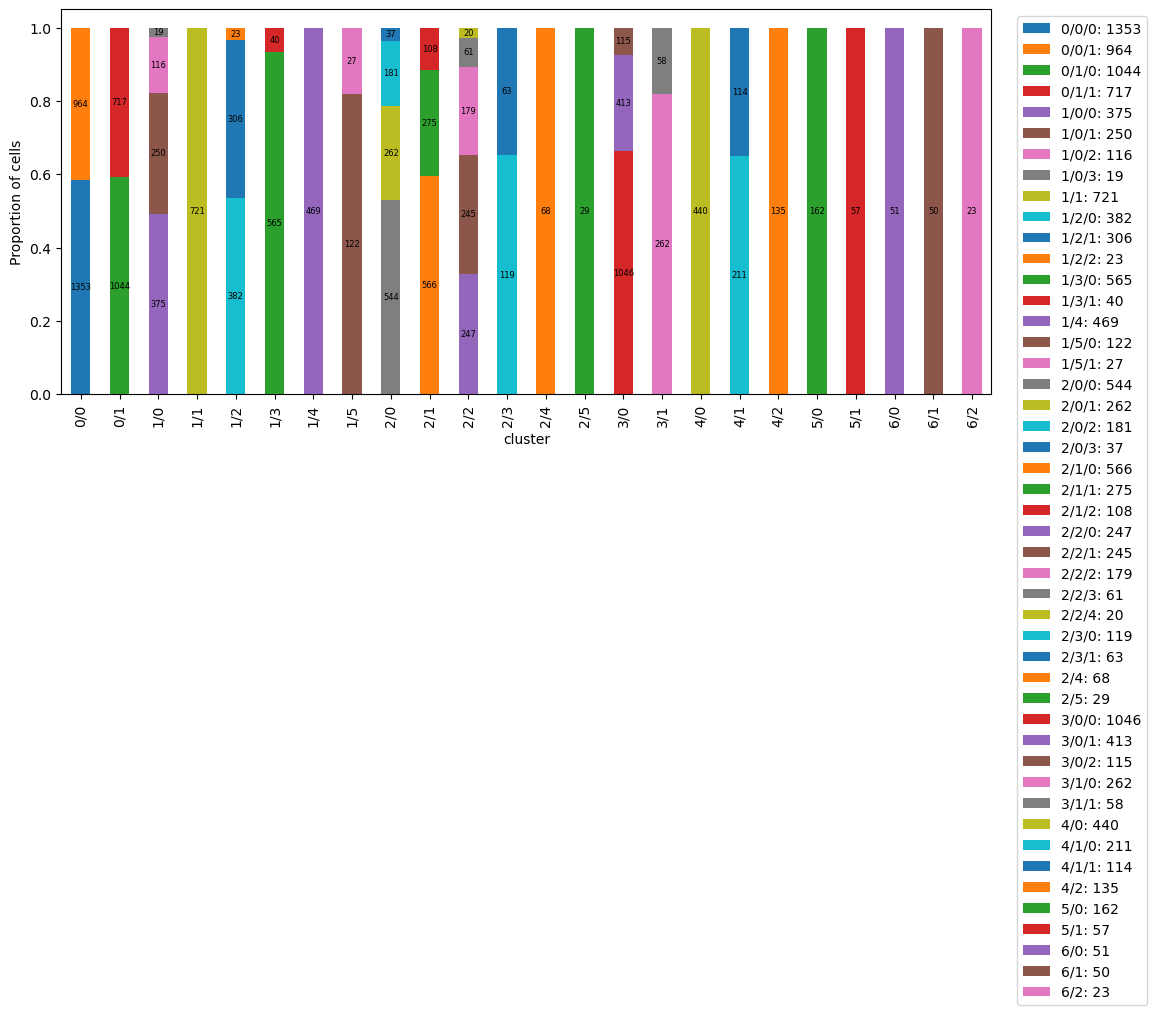

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. raw counts
counts = pd.crosstab(
    adata.obs['cluster'],
    adata.obs['subcluster']
)

# 2. proportions
proportions = counts.div(counts.sum(1), axis=0)

# 3. plot stacked bars
ax = proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12,5),
    ylabel='Proportion of cells'
)

# 4. annotate bars with absolute counts
for i, supercluster in enumerate(counts.index):
    bottom = 0

    for cluster in counts.columns:
        value = proportions.loc[supercluster, cluster]
        raw = counts.loc[supercluster, cluster]

        if raw == 0:
            continue

        # cutoff = 0.1 (your request)
        if value < 0.01:
            bottom += value
            continue

        ax.text(
            i,
            bottom + value / 2,
            str(int(raw)),
            ha='center',
            va='center',
            fontsize=6
        )

        bottom += value

# 5. rebuild legend with counts included
handles, labels = ax.get_legend_handles_labels()

new_labels = [
    f"{label}: {counts[label].sum()}"
    for label in labels
]

ax.legend(
    handles,
    new_labels,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [ ]:
adata.obs[['supercluster', 'cluster', 'subcluster']].to_csv(f"../results/{region}_recursive_hpo_subclustering_labels.csv")

In [24]:
adata

AnnData object with n_obs × n_vars = 13634 × 17592
    obs: 'species', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_tf', 'log1p_total_counts_tf', 'pct_counts_tf', 'n_counts', 'qc_composite', 'qc_label', 'sample_id', 'replicate', 'supercluster', 'silhouette_score', 'cluster', 'subcluster'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 